<a href="https://colab.research.google.com/github/anshisboss/Steps-AI/blob/main/raptor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas umap-learn sentence-transformers scikit-learn torch langchain langchain-core langchain-community llama-cpp-python nltk typing torch chromadb


Exception in thread Thread-5 (attachment_entry):
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/debugpy/server/api.py", line 237, in listen
    sock, _ = endpoints_listener.accept()
  File "/usr/lib/python3.10/socket.py", line 293, in accept
    fd, addr = self._accept()
TimeoutError: timed out

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.10/dist-packages/google/colab/_debugpy.py", line 52, in attachment_entry
    debugpy.listen(_dap_port)
  File "/usr/local/lib/python3.10/dist-packages/debugpy/public_api.py", line 31, in wrapper
    return wrapped(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/debugpy/server/api.py", line 143, in debug
    log.reraise

In [4]:
!pip install PyPDF2 nltk matplotlib numpy scikit-learn sentence-transformers pandas umap-learn tiktoken llama-cpp-python


  Using cached pypdf2-3.0.1-py3-none-any.whl (232 kB)
  Using cached tiktoken-0.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.1 MB)


In [2]:
!wget "https://huggingface.co/TheBloke/zephyr-7B-beta-GGUF/resolve/main/zephyr-7b-beta.Q4_K_M.gguf"


--2024-07-19 11:38:13--  https://huggingface.co/TheBloke/zephyr-7B-beta-GGUF/resolve/main/zephyr-7b-beta.Q4_K_M.gguf
Resolving huggingface.co (huggingface.co)... 3.163.189.90, 3.163.189.37, 3.163.189.74, ...
Connecting to huggingface.co (huggingface.co)|3.163.189.90|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.huggingface.co/repos/fe/17/fe17596731f84a0d03bece77489780bc7e068323c0aeca88b6393d3e9e65dd49/503580dce392c6e64669ad21a77023ba2a17baa0c381250fb67c11ba6406a85e?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27zephyr-7b-beta.Q4_K_M.gguf%3B+filename%3D%22zephyr-7b-beta.Q4_K_M.gguf%22%3B&Expires=1721648293&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTcyMTY0ODI5M319LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmh1Z2dpbmdmYWNlLmNvL3JlcG9zL2ZlLzE3L2ZlMTc1OTY3MzFmODRhMGQwM2JlY2U3NzQ4OTc4MGJjN2UwNjgzMjNjMGFlY2E4OGI2MzkzZDNlOWU2NWRkNDkvNTAzNTgwZGNlMzkyYzZlNjQ2NjlhZDIxYTc3MDIzYmEyYTE

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


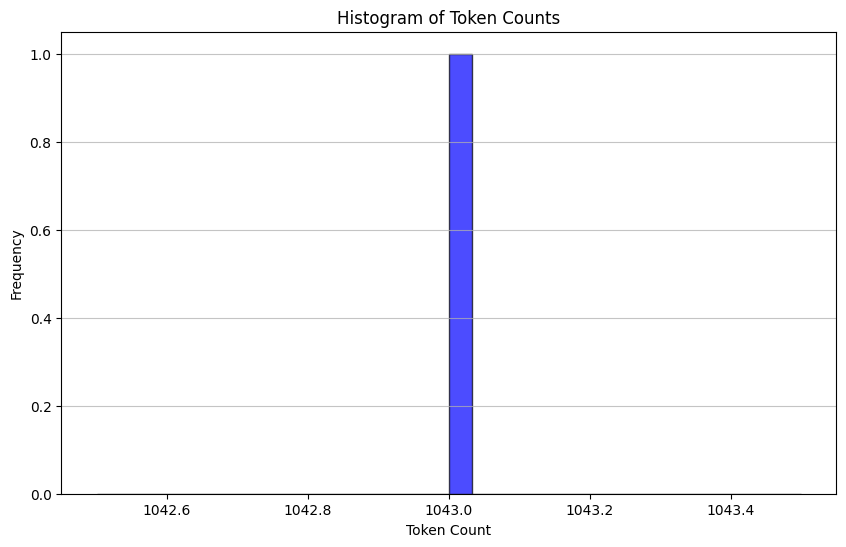

Num tokens in all context: 1043
Number of text splits generated: 15
384
[17.2768   11.132486]


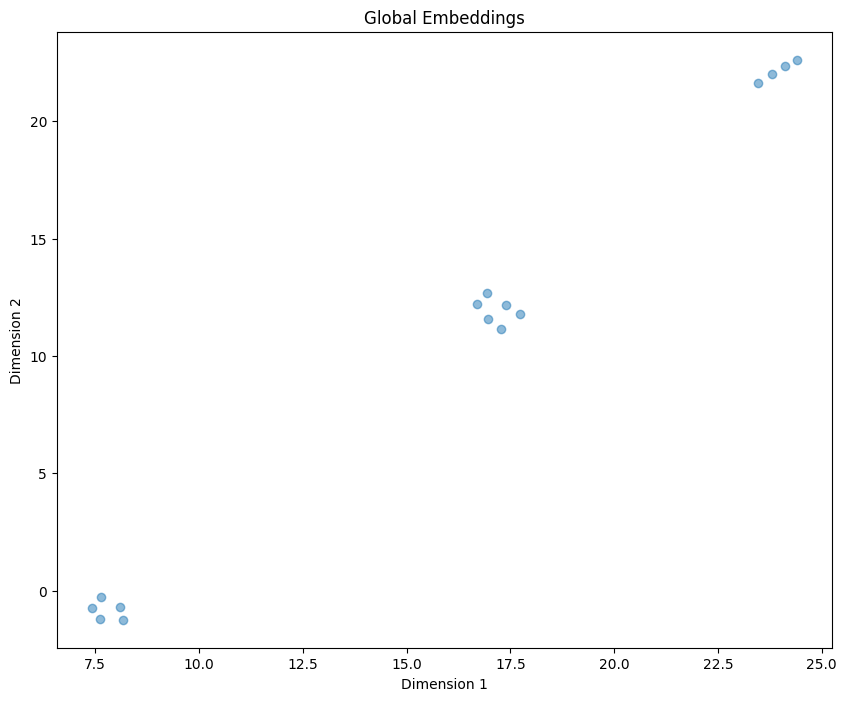

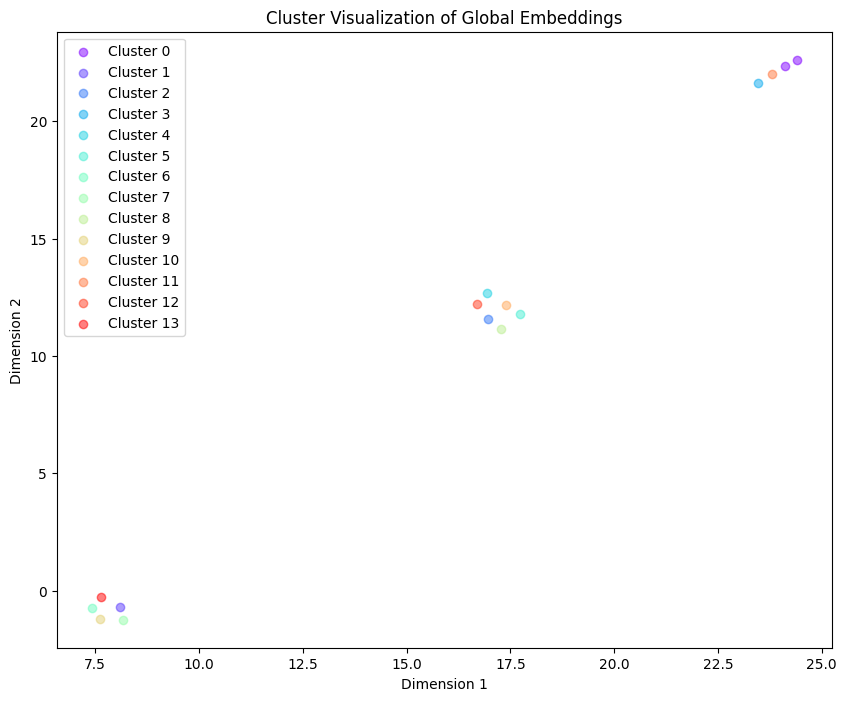

                                                Text               Embedding  \
0  Ansh  Chawla  \nLeetcode:  averageDPEnjoyer  E...    [17.2768, 11.132486]   
1  • Shiv  Nadar  Institution  of Eminence  Delhi...  [16.703787, 12.229376]   
2  • Ahlcon  Public  School  Delhi,  India CBSE  ...  [16.949024, 12.688538]   

   Cluster  
0        8  
1       12  
2        4  
Cluster 8:
Ansh  Chawla  
Leetcode:  averageDPEnjoyer  Email:  ansh.work2002@gmail.com  
GeeksforGeeks:  bowlansh  Mobile:   +919810536968  
EDUCATION

Cluster 12:
• Shiv  Nadar  Institution  of Eminence  Delhi NCR,  India Bachelor  of Technology  - Computer  Science  and Engineering;  June  2024  
Courses:  Operating Systems, Data Structures, Object Oriented Programming, Design and Analysis Of Algorithms, Software Engineering, 
Networking, Database Management System, Information Retrieval

Cluster 4:
• Ahlcon  Public  School  Delhi,  India CBSE  XII; Percentage:  91 May  2020  
Courses:  Maths,  Chemistry,  Physics,  E

In [6]:
import PyPDF2
import nltk
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
from sentence_transformers import SentenceTransformer
import pandas as pd
import umap
import tiktoken
from langchain.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores.utils import DistanceStrategy
from typing import Dict, List, Optional, Tuple

# Initialize Chroma client

#
EMBEDDING_MODEL_NAME = "thenlper/gte-small"

embd = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},  # set True for cosine similarity
)


nltk.download("punkt")


def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            text += page.extract_text()
    return text

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# Extract content from the PDF
pdf_path = "rand.pdf"
text_content = extract_text_from_pdf(pdf_path)

# print((text_content))


# Create a list of documents from the extracted text
# Assuming `text_content` is a single string, split it into chunks if necessary
docs = [{"page_content": text_content, "metadata": {"source": pdf_path}}]

# Extract texts from the documents
docs_texts = [doc["page_content"] for doc in docs]

# Process the document texts


counts = [num_tokens_from_string(d, "cl100k_base") for d in docs_texts]

# Plotting the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Histogram of Token Counts")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

# Display the histogram
plt.show()

d_sorted = sorted(docs, key=lambda x: x["metadata"]["source"])
d_reversed = list(reversed(d_sorted))
concatenated_content = "\n\n\n --- \n\n\n".join(
    [doc["page_content"] for doc in d_reversed]
)
print(
    "Num tokens in all context: %s"
    % num_tokens_from_string(concatenated_content, "cl100k_base")
)

chunk_size_tok = 100

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=chunk_size_tok, chunk_overlap=0
)
texts_split = text_splitter.split_text(concatenated_content)
#
print(f"Number of text splits generated: {len(texts_split)}")

# Print number of text splits generated
global_embeddings = [embd.embed_query(txt) for txt in texts_split]


print(len(global_embeddings[0]))




def reduce_cluster_embeddings(
    embeddings: np.ndarray,
    dim: int,
    n_neighbors: Optional[int] = None,
    metric: str = "cosine",
) -> np.ndarray:
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


dim = 2
global_embeddings_reduced = reduce_cluster_embeddings(global_embeddings, dim)
print(global_embeddings_reduced[0])

plt.figure(figsize=(10, 8))
plt.scatter(global_embeddings_reduced[:, 0], global_embeddings_reduced[:, 1], alpha=0.5)
plt.title("Global Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()




def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = 1234
):
    max_clusters = min(max_clusters, len(embeddings))
    bics = [
        GaussianMixture(n_components=n, random_state=random_state)
        .fit(embeddings)
        .bic(embeddings)
        for n in range(1, max_clusters)
    ]
    return np.argmin(bics) + 1


def gmm_clustering(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state).fit(
        embeddings
    )
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters


labels, _ = gmm_clustering(global_embeddings_reduced, threshold=0.5)

plot_labels = np.array([label[0] if len(label) > 0 else -1 for label in labels])
plt.figure(figsize=(10, 8))

unique_labels = np.unique(plot_labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = plot_labels == label
    plt.scatter(
        global_embeddings_reduced[mask, 0],
        global_embeddings_reduced[mask, 1],
        color=color,
        label=f"Cluster {label}",
        alpha=0.5,
    )

plt.title("Cluster Visualization of Global Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()


# Create a dataframe to check the texts associated with each cluster
simple_labels = [label[0] if len(label) > 0 else -1 for label in labels]

df = pd.DataFrame(
    {
        "Text": texts_split,
        "Embedding": list(global_embeddings_reduced),
        "Cluster": simple_labels,
    }
)
print(df.head(3))


# Function to format clustered texts
# def format_cluster_texts(df):
#     clustered_texts = {}
#     for cluster in df["Cluster"].unique():
#         cluster_texts = df[df["Cluster"] == cluster]["Text"].tolist()
#         clustered_texts[cluster] = " --- ".join(cluster_texts)
#         print(f"Cluster {cluster}:\n{clustered_texts[cluster]}\n")
#     return clustered_texts


# make above function more debuggable along with how much left
def format_cluster_texts(df):
    clustered_texts = {}
    for cluster in df["Cluster"].unique():
        cluster_texts = df[df["Cluster"] == cluster]["Text"].tolist()
        clustered_texts[cluster] = " --- ".join(cluster_texts)
        print(f"Cluster {cluster}:\n{clustered_texts[cluster]}\n")
    print(f"Total clusters: {len(clustered_texts)}")
    return clustered_texts


clustered_texts = format_cluster_texts(df)

# Print clustered texts
for cluster, text in clustered_texts.items():
    print(f"Cluster {cluster}:\n{text}\n")


In [9]:
!pip install -U langchain umap-learn scikit-learn langchain_community tiktoken langchain-openai langchainhub chromadb
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 38.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.6/328.6 kB 30.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


In [ ]:
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import umap
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from sentence_transformers import SentenceTransformer
from langchain_community.llms.llamacpp import LlamaCpp
from langchain_core.callbacks import CallbackManager, StreamingStdOutCallbackHandler
from langchain_core.prompts import PromptTemplate, HumanMessagePromptTemplate
from langchain import hub
from sklearn.mixture import GaussianMixture
# from chromadb import Client as ChromaClient
from langchain_core.runnables import RunnablePassthrough
import torch
# Initialize the SentenceTransformer on CPU



# Initialize the LlamaCpp model for summarization
n_gpu_layers = -1
n_batch = 512
callback_manager = CallbackManager([StreamingStdOutCallbackHandler()])

RANDOM_SEED = 224  # Fixed seed for reproducibility

# Initialize LlamaCpp model
model = LlamaCpp(
    model_path="zephyr-7b-beta.Q4_K_M.gguf",
    n_gpu_layers=n_gpu_layers,
    n_batch=n_batch,
    temperature=0.75,
    max_tokens=1000,
    top_p=1,
    n_ctx=35000,
    callback_manager=callback_manager,
    verbose=True,
)

print("Initialized LlamaCpp model")

# Function definitions



RANDOM_SEED = 224  # Fixed seed for reproducibility

### --- Code from citations referenced above (added comments and docstrings) --- ###


def global_cluster_embeddings(
    embeddings: np.ndarray,
    dim: int,
    n_neighbors: Optional[int] = None,
    metric: str = "cosine",
) -> np.ndarray:
    """
    Perform global dimensionality reduction on the embeddings using UMAP.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for the reduced space.
    - n_neighbors: Optional; the number of neighbors to consider for each point.
                   If not provided, it defaults to the square root of the number of embeddings.
    - metric: The distance metric to use for UMAP.

    Returns:
    - A numpy array of the embeddings reduced to the specified dimensionality.
    """
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


def local_cluster_embeddings(
    embeddings: np.ndarray, dim: int, num_neighbors: int = 10, metric: str = "cosine"
) -> np.ndarray:
    """
    Perform local dimensionality reduction on the embeddings using UMAP, typically after global clustering.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for the reduced space.
    - num_neighbors: The number of neighbors to consider for each point.
    - metric: The distance metric to use for UMAP.

    Returns:
    - A numpy array of the embeddings reduced to the specified dimensionality.
    """
    return umap.UMAP(
        n_neighbors=num_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """
    Determine the optimal number of clusters using the Bayesian Information Criterion (BIC) with a Gaussian Mixture Model.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - max_clusters: The maximum number of clusters to consider.
    - random_state: Seed for reproducibility.

    Returns:
    - An integer representing the optimal number of clusters found.
    """
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]


def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    """
    Cluster embeddings using a Gaussian Mixture Model (GMM) based on a probability threshold.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - threshold: The probability threshold for assigning an embedding to a cluster.
    - random_state: Seed for reproducibility.

    Returns:
    - A tuple containing the cluster labels and the number of clusters determined.
    """
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters


def perform_clustering(
    embeddings: np.ndarray,
    dim: int,
    threshold: float,
) -> List[np.ndarray]:
    """
    Perform clustering on the embeddings by first reducing their dimensionality globally, then clustering
    using a Gaussian Mixture Model, and finally performing local clustering within each global cluster.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - dim: The target dimensionality for UMAP reduction.
    - threshold: The probability threshold for assigning an embedding to a cluster in GMM.

    Returns:
    - A list of numpy arrays, where each array contains the cluster IDs for each embedding.
    """
    if len(embeddings) <= dim + 1:
        # Avoid clustering when there's insufficient data
        return [np.array([0]) for _ in range(len(embeddings))]

    # Global dimensionality reduction
    reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)
    # Global clustering
    global_clusters, n_global_clusters = GMM_cluster(
        reduced_embeddings_global, threshold
    )

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    # Iterate through each global cluster to perform local clustering
    for i in range(n_global_clusters):
        # Extract embeddings belonging to the current global cluster
        global_cluster_embeddings_ = embeddings[
            np.array([i in gc for gc in global_clusters])
        ]

        if len(global_cluster_embeddings_) == 0:
            continue
        if len(global_cluster_embeddings_) <= dim + 1:
            # Handle small clusters with direct assignment
            local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
            n_local_clusters = 1
        else:
            # Local dimensionality reduction and clustering
            reduced_embeddings_local = local_cluster_embeddings(
                global_cluster_embeddings_, dim
            )
            local_clusters, n_local_clusters = GMM_cluster(
                reduced_embeddings_local, threshold
            )

        # Assign local cluster IDs, adjusting for total clusters already processed
        for j in range(n_local_clusters):
            local_cluster_embeddings_ = global_cluster_embeddings_[
                np.array([j in lc for lc in local_clusters])
            ]
            indices = np.where(
                (embeddings == local_cluster_embeddings_[:, None]).all(-1)
            )[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(
                    all_local_clusters[idx], j + total_clusters
                )

        total_clusters += n_local_clusters

    return all_local_clusters


### --- Our code below --- ###


def embed(texts):
    """
    Generate embeddings for a list of text documents.

    This function assumes the existence of an `embd` object with a method `embed_documents`
    that takes a list of texts and returns their embeddings.

    Parameters:
    - texts: List[str], a list of text documents to be embedded.

    Returns:
    - numpy.ndarray: An array of embeddings for the given text documents.
    """
    text_embeddings = embd.embed_documents(texts)
    text_embeddings_np = np.array(text_embeddings)
    return text_embeddings_np


def embed_cluster_texts(texts):
    """
    Embeds a list of texts and clusters them, returning a DataFrame with texts, their embeddings, and cluster labels.

    This function combines embedding generation and clustering into a single step. It assumes the existence
    of a previously defined `perform_clustering` function that performs clustering on the embeddings.

    Parameters:
    - texts: List[str], a list of text documents to be processed.

    Returns:
    - pandas.DataFrame: A DataFrame containing the original texts, their embeddings, and the assigned cluster labels.
    """
    text_embeddings_np = embed(texts)  # Generate embeddings
    cluster_labels = perform_clustering(
        text_embeddings_np, 10, 0.1
    )  # Perform clustering on the embeddings
    df = pd.DataFrame()  # Initialize a DataFrame to store the results
    df["text"] = texts  # Store original texts
    df["embd"] = list(text_embeddings_np)  # Store embeddings as a list in the DataFrame
    df["cluster"] = cluster_labels  # Store cluster labels
    return df


def fmt_txt(df: pd.DataFrame) -> str:
    """
    Formats the text documents in a DataFrame into a single string.

    Parameters:
    - df: DataFrame containing the 'text' column with text documents to format.

    Returns:
    - A single string where all text documents are joined by a specific delimiter.
    """
    unique_txt = df["text"].tolist()
    unique_txt = [str(text) for text in unique_txt]  # Convert to string if necessary
    return "--- --- \n --- --- ".join(unique_txt)


def embed_cluster_summarize_texts(
    texts: List[str], level: int
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Embeds, clusters, and summarizes a list of texts. This function first generates embeddings for the texts,
    clusters them based on similarity, expands the cluster assignments for easier processing, and then summarizes
    the content within each cluster.

    Parameters:
    - texts: A list of text documents to be processed.
    - level: An integer parameter that could define the depth or detail of processing.

    Returns:
    - Tuple containing two DataFrames:
      1. The first DataFrame (`df_clusters`) includes the original texts, their embeddings, and cluster assignments.
      2. The second DataFrame (`df_summary`) contains summaries for each cluster, the specified level of detail,
         and the cluster identifiers.
    """

    # Embed and cluster the texts, resulting in a DataFrame with 'text', 'embd', and 'cluster' columns
    df_clusters = embed_cluster_texts(texts)

    # Prepare to expand the DataFrame for easier manipulation of clusters
    expanded_list = []

    # Expand DataFrame entries to document-cluster pairings for straightforward processing
    for index, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append(
                {"text": row["text"], "embd": row["embd"], "cluster": cluster}
            )

    # Create a new DataFrame from the expanded list
    expanded_df = pd.DataFrame(expanded_list)

    # Retrieve unique cluster identifiers for processing
    all_clusters = expanded_df["cluster"].unique()

    print(f"--Generated {len(all_clusters)} clusters--")

    # Summarization
    template = """Here is a subset of a project report on a project done on lossless compression. By a student
    Give a detailed summary of the documentation provided.

    Documentation:
    {context}
    """
    prompt = ChatPromptTemplate.from_template(template)
    chain = prompt | model | StrOutputParser()

    # Format text within each cluster for summarization
    summaries = []
    for i in all_clusters:
        df_cluster = expanded_df[expanded_df["cluster"] == i]
        formatted_txt = fmt_txt(df_cluster)
        summaries.append(chain.invoke({"context": formatted_txt}))

    # Create a DataFrame to store summaries with their corresponding cluster and level
    df_summary = pd.DataFrame(
        {
            "summaries": summaries,
            "level": [level] * len(summaries),
            "cluster": list(all_clusters),
        }
    )

    return df_clusters, df_summary


def recursive_embed_cluster_summarize(
    texts: List[str], level: int = 1, n_levels: int = 3
) -> Dict[int, Tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Recursively embeds, clusters, and summarizes texts up to a specified level or until
    the number of unique clusters becomes 1, storing the results at each level.

    Parameters:
    - texts: List[str], texts to be processed.
    - level: int, current recursion level (starts at 1).
    - n_levels: int, maximum depth of recursion.

    Returns:
    - Dict[int, Tuple[pd.DataFrame, pd.DataFrame]], a dictionary where keys are the recursion
      levels and values are tuples containing the clusters DataFrame and summaries DataFrame at that level.
    """
    results = {}  # Dictionary to store results at each level

    # Perform embedding, clustering, and summarization for the current level
    df_clusters, df_summary = embed_cluster_summarize_texts(texts, level)

    # Store the results of the current level
    results[level] = (df_clusters, df_summary)

    # Determine if further recursion is possible and meaningful
    unique_clusters = df_summary["cluster"].nunique()
    if level < n_levels and unique_clusters > 1:
        # Use summaries as the input texts for the next level of recursion
        new_texts = df_summary["summaries"].tolist()
        next_level_results = recursive_embed_cluster_summarize(
            new_texts, level + 1, n_levels
        )

        # Merge the results from the next level into the current results dictionary
        results.update(next_level_results)

    return results

# Execution starts here
print("Starting the process")

leaf_texts = docs_texts
results = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels=3)

all_texts = leaf_texts.copy()

# Iterate through the results to extract summaries from each level and add them to all_texts
for level in sorted(results.keys()):
    # Extract summaries from the current level's DataFrame
    summaries = results[level][1]["summaries"].tolist()
    # Extend all_texts with the summaries from the current level
    all_texts.extend(summaries)

print(all_texts)

print("Final Summaries extracted")

vectorstore = Chroma.from_texts(texts=all_texts, embedding=embd)
retriever = vectorstore.as_retriever()

prompt = hub.pull("rlm/rag-prompt")


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

print(prompt)
print(prompt.messages[0].prompt.template)

response = rag_chain.invoke(
    "What college is the student from ?"
)
print("Response received:")
print(str(response))


llama_model_loader: loaded meta data with 21 key-value pairs and 291 tensors from zephyr-7b-beta.Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = huggingfaceh4_zephyr-7b-beta
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loader: - kv   6:                 llama.rope.dimension_count u32              = 128
llama_model_loader: - kv   7:                 llama.attention.h

Initialized LlamaCpp model
Starting the process
--Generated 1 clusters--

Based on the provided documentation, summarize Ansh Chawla's education background, skills summary, work experience, and notable projects.


llama_print_timings:        load time =  199225.07 ms
llama_print_timings:      sample time =      23.31 ms /    30 runs   (    0.78 ms per token,  1286.84 tokens per second)
llama_print_timings: prompt eval time =  511000.70 ms /  1270 tokens (  402.36 ms per token,     2.49 tokens per second)
llama_print_timings:        eval time =  491846.72 ms /    29 runs   (16960.23 ms per token,     0.06 tokens per second)
llama_print_timings:       total time = 1003069.52 ms /  1299 tokens


['Ansh  Chawla  \nLeetcode:  averageDPEnjoyer  Email:  ansh.work2002@gmail.com  \nGeeksforGeeks:  bowlansh  Mobile:   +919810536968  \nEDUCATION  \n• Shiv  Nadar  Institution  of Eminence  Delhi NCR,  India Bachelor  of Technology  - Computer  Science  and Engineering;  June  2024  \nCourses:  Operating Systems, Data Structures, Object Oriented Programming, Design and Analysis Of Algorithms, Software Engineering, \nNetworking, Database Management System, Information Retrieval  \n• Ahlcon  Public  School  Delhi,  India CBSE  XII; Percentage:  91 May  2020  \nCourses:  Maths,  Chemistry,  Physics,  English  \nSKILLS  SUMMARY  \n• Languages : Python,  Java,  C++, SQL \n• Tools : MySQL,  Node.JS,  Google  Cloud  Platform,  ElasticSearch,  SpringBoot,Sentence  Transformers , Rasa, Streamlit, \nKibana ,Ollama  \nEXPERIENCE  \n• HealthKart  Gurugram,Harayana Software  Development  Intern  Jan 2024  - Present  \n• Transformed  Search : Worked on transition from keyword matching to vector -base

Llama.generate: prefix-match hit


 The student's college is Shiv Nadar Institution of Eminence Delhi NCR, where they are pursuing